# Taller: Análisis de Sentimientos en Tweets en Español (TASS 2018)

En este notebook vamos a construir paso a paso un clasificador de sentimiento para tweets en español utilizando el corpus de **TASS 2018**.  
El objetivo pedagógico es entender cada etapa típica de un *pipeline* de NLP aplicado a clasificación de texto:

1. Contexto del problema y del corpus TASS.
2. Configuración del entorno de trabajo.
3. Carga y exploración de los datos.
4. Preprocesamiento de texto en español.
5. Representación mediante **Bolsa de Palabras (Bag of Words)**.
6. Manejo del desbalance de clases.
7. Definición y entrenamiento de un modelo **Softmax (Regresión Logística Multinomial)**.
8. Evaluación con métricas de clasificación y matriz de confusión.

Cada bloque de código irá precedido de una breve explicación en español para que el flujo completo sea fácil de seguir en el taller.


## 1. Configuración del entorno

En este bloque definimos la ruta donde se encuentran los datos de TASS y añadimos el directorio actual al `sys.path` para poder importar módulos locales (por ejemplo, la clase `TextProcessing` que usaremos para el preprocesamiento).


In [ ]:
import os
import sys
PATH = os.getcwd()
DIR_DATA = PATH + '{0}tass{0}'.format(os.sep)
sys.path.append(PATH) if PATH not in list(sys.path) else None
DIR_DATA

'/content/tass/'

In [ ]:
print(os.listdir(DIR_DATA))

['tass2018_es_test.csv', 'tass2018_es_train.csv']


## 2. Contexto: TASS 2018

**TASS** es una campaña de evaluación y taller científico centrado en el **análisis de sentimientos en Twitter en español**.  
En la edición 2018, una de las tareas principales consiste en predecir la **polaridad global** de cada tweet (por ejemplo, positiva, negativa, neutra, etc.) a partir de texto corto, ruidoso y con variantes dialectales.

En este taller utilizaremos una versión de ese corpus para entrenar un modelo supervisado de clasificación de sentimiento.

Más información: <http://tass.sepln.org/2018/>


## 3. Importación de librerías

En el siguiente bloque importamos las librerías necesarias para:

- Manipular datos (`pandas`, `numpy`).
- Visualizar resultados (`matplotlib`, `seaborn`).
- Preprocesar y transformar texto (`TextProcessing`, `CountVectorizer`).
- Construir y evaluar modelos (`LogisticRegression`, métricas de `sklearn`).
- Tratar el desbalance de clases (`RandomOverSampler`).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from logic.text_processing import TextProcessing
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, recall_score, log_loss, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, accuracy_score, precision_score
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sentence_transformers import SentenceTransformer
import spacy
#!python -m spacy download es_core_news_sm
import importlib
import logic.text_processing as tp_module
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

## 4. Inicialización de utilidades de preprocesamiento

Instanciamos:

- `TextProcessing()`: encapsula las transformaciones de texto (limpieza, normalización, etc.).
- `LabelEncoder()`: utilidad para mapear etiquetas de texto a códigos numéricos si fuera necesario.

Esto nos permite mantener el preprocesamiento separado de la lógica del modelo.


In [ ]:
tp = TextProcessing()
le = LabelEncoder()

Language: Text Processing
es: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 5. Carga de los conjuntos de entrenamiento y prueba

A continuación cargamos:

- **`tass2018_es_train.csv`**: tweets etiquetados con su polaridad (conjunto de entrenamiento).
- **`tass2018_es_test.csv`**: tweets separados para evaluación final.

Es importante que durante el taller se explique el formato de las columnas (por ejemplo: identificador, contenido del tweet, etiqueta de polaridad).

In [ ]:
data_train = pd.read_csv(DIR_DATA + 'tass2018_es_train.csv', sep=',')
print(f"Tamaño del dataset: {len(data_train)}")
data_train[:3]

Tamaño del dataset: 1008


,tweetid,user,content,date,lang,sentiment/polarity/value
0,768213876278165504,OnceBukowski,-Me caes muy bien \n-Tienes que jugar más part...,2016-08-23 22:30:35,es,NONE
1,768213567418036224,anahorxn,@myendlesshazza a. que puto mal escribo\n\nb. ...,2016-08-23 22:29:21,es,N
2,768212591105703936,martitarey13,@estherct209 jajajaja la tuya y la d mucha gen...,2016-08-23 22:25:29,es,N


In [ ]:
data_test = pd.read_csv(DIR_DATA + 'tass2018_es_test.csv', sep=',')
print(f"Tamaño del dataset: {len(data_test)}")
data_test[:3]

Tamaño del dataset: 506


,tweetid,user,content,date,lang,sentiment/polarity/value
0,770976639173951488,noseashetero,@noseashetero 1000/10 de verdad a ti que voy a...,2016-08-31 13:28:49,es,P
1,771092421866389508,Templelx,@piscolabisaereo @HistoriaNG @SPosteguillo las...,2016-08-31 21:08:54,es,P
2,771092111429083136,esskuu94,"Al final han sido 3h Bueno, mañana tengo fies...",2016-08-31 21:07:40,es,P


## 6. Preprocesamiento de texto

In [ ]:
# Forzar recarga del módulo actualizado
importlib.reload(tp_module)

tp = TextProcessing()

Language: Text Processing
es: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [ ]:
data_train['content'].tolist()[:15]

['-Me caes muy bien \n-Tienes que jugar más partidas al lol con Russel y conmigo\n-Por qué tan Otako, deja de ser otako\n-Haber si me muero',
 '@myendlesshazza a. que puto mal escribo\n\nb. me sigo surrando help \n\n3. ha quedado raro el "cómetelo" ahí JAJAJAJA',
 '@estherct209 jajajaja la tuya y la d mucha gente seguro!! Pero yo no puedo sin mi melena me muero',
 'Quiero mogollón a @AlbaBenito99 pero sobretodo por lo rápido que contesta a los wasaps',
 'Vale he visto la tia bebiendose su regla y me hs dado muchs grima',
 '@Yulian_Poe @guillermoterry1 Ah. mucho más por supuesto! solo que lo incluyo. Me habías entendido mal',
 'Se ha terminado #Rio2016 Lamentablemente no arriendo las ganancias al pueblo brasileño por la penuria que les espera \nSuerte y solidaridad',
 '11. siiii fue super gracioso teniamos que habernos sacado una foto',
 '@toNi_end seria mejor que dejasen de emitir esa basura ya  hay que evolucionar para bien y eso',
 '@jonoro96 te mandaria a comprarte un burro, pero no

In [ ]:
# Aplicar el nuevo preprocesamiento al dataset completo
x_train_v2 = [tp.transformer(row, preserve_hashtags=True, preserve_emojis=True)
               for row in data_train['content'].tolist()]

x_test_v2  = [tp.transformer(row, preserve_hashtags=True, preserve_emojis=True)
               for row in data_test['content'].tolist()]

y_train = data_train['sentiment/polarity/value']
y_test = data_test['sentiment/polarity/value']

# Ver cuántos tweets tienen hashtags o emojis semánticos
import re
con_hashtag = sum(1 for t in x_train_v2 if t and 'hashtag_' in t)
con_emoji   = sum(1 for t in x_train_v2 if t and 'emoji_'   in t)
print(f"\nTweets con hashtag preservado : {con_hashtag}")
print(f"Tweets con emoji semántico     : {con_emoji}")


Tweets con hashtag preservado : 72
Tweets con emoji semántico     : 17


## 7. Representación: Bolsa de Palabras (Bag of Words)

El modelo no puede trabajar directamente con texto, así que lo convertimos en vectores numéricos.

Usamos `CountVectorizer` con:

- `analyzer='word'`
- `ngram_range=(1, 3)` para incluir unigramas, bigramas y trigramas.

Cada tweet se representa como un vector donde cada posición corresponde a una palabra o n-grama del vocabulario y el valor es su frecuencia en el tweet.


In [ ]:
# 7. Representación: Bag of Words
# IMPORTANTE: usamos x_train_v2 y x_test_v2 (preprocesamiento mejorado)
# y filtramos None por si algún tweet quedó vacío tras el preprocesamiento

x_train_clean = [t if t is not None else '' for t in x_train_v2]
x_test_clean  = [t if t is not None else '' for t in x_test_v2]

bow = CountVectorizer(analyzer='word', ngram_range=(1, 3))

x_train_bow = bow.fit_transform(x_train_clean)
x_test_bow  = bow.transform(x_test_clean)

print(f"Vocabulario total     : {len(bow.vocabulary_)} n-gramas")
print(f"Shape train           : {x_train_bow.shape}")  # (tweets, n-gramas)
print(f"Shape test            : {x_test_bow.shape}")

# Ver algunos n-gramas del vocabulario con tokens semánticos
vocab_sample = [k for k in bow.vocabulary_.keys() if 'hashtag' in k or 'emoji' in k]
print(f"\nTokens semánticos en vocabulario: {len(vocab_sample)}")
print(vocab_sample[:20])

Vocabulario total     : 26191 n-gramas
Shape train           : (1008, 26191)
Shape test            : (506, 26191)

Tokens semánticos en vocabulario: 481
['hashtag_rio2016', 'terminado hashtag_rio2016', 'hashtag_rio2016 lamentablemente', 'ha terminado hashtag_rio2016', 'terminado hashtag_rio2016 lamentablemente', 'hashtag_rio2016 lamentablemente no', 'emoji_feliz', 'aqui emoji_feliz', 'emoji_feliz si', 'estoy aqui emoji_feliz', 'aqui emoji_feliz si', 'emoji_feliz si no', 'hashtag_mataro', 'hashtag_felicidad', 'de hashtag_mataro', 'hashtag_mataro hashtag_felicidad', 'familia de hashtag_mataro', 'de hashtag_mataro hashtag_felicidad', 'hashtag_incantus', 'mention hashtag_incantus']


## 8. Análisis de distribución de clases

Antes de entrenar, observamos cuántos ejemplos hay por clase en entrenamiento y prueba.  
Esto nos permite detectar si el conjunto está **desbalanceado** (por ejemplo, muchas más opiniones neutrales que negativas), algo habitual en tareas reales.


In [ ]:
print('Sample train:', sorted(Counter(y_train).items()))
# porcentaje de diferencia
train_counts = Counter(y_train)
total_train_samples = sum(train_counts.values())
print("Distribución porcentual de clases en el conjunto de entrenamiento:")
for label, count in sorted(train_counts.items()):
    percentage = (count / total_train_samples) * 100
    print(f"  {label}: {percentage:.2f}%")
print()

Sample train: [('N', 418), ('NEU', 133), ('NONE', 139), ('P', 318)]
Distribución porcentual de clases en el conjunto de entrenamiento:
  N: 41.47%
  NEU: 13.19%
  NONE: 13.79%
  P: 31.55%



In [ ]:
print('Sample test:', sorted(Counter(y_test).items()))
# porcentaje de diferencia
test_counts = Counter(y_test)
total_test_samples = sum(test_counts.values())
print("Distribución porcentual de clases en el conjunto de prueba:")
for label, count in sorted(test_counts.items()):
    percentage = (count / total_test_samples) * 100
    print(f"  {label}: {percentage:.2f}%")
print()

Sample test: [('N', 219), ('NEU', 69), ('NONE', 62), ('P', 156)]
Distribución porcentual de clases en el conjunto de prueba:
  N: 43.28%
  NEU: 13.64%
  NONE: 12.25%
  P: 30.83%



## 9. Esquema de validación: ShuffleSplit (Validación Cruzada)

Para estimar el rendimiento del modelo de forma más robusta usamos `ShuffleSplit`:

- Se generan varias particiones aleatorias (aquí, 10).
- En cada partición se entrena con una parte de los datos y se evalúa con el resto.

Esto ayuda a reducir la dependencia de una única partición entrenamiento/prueba.


In [ ]:
k_fold = ShuffleSplit(n_splits=10, test_size=0.25, random_state=42)

## 10. Manejo del desbalance de clases

In [ ]:
# 1. Random Over puro (baseline)
ros = RandomOverSampler(random_state=42)
x_train_over, y_train_over = ros.fit_resample(x_train_bow, y_train)

# 2. Random Under puro
rus = RandomUnderSampler(random_state=42)
x_train_under, y_train_under = rus.fit_resample(x_train_bow, y_train)

# 3. SMOTE puro
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_bow, y_train)

# 4. SMOTETomek
smotetomek = SMOTETomek(random_state=42)
x_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(x_train_bow, y_train)

# 5. SMOTEENN
smoteenn = SMOTEENN(random_state=42)
x_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(x_train_bow, y_train)

# ── Resumen comparativo ──────────────────────────────────────────────────────
tecnicas = {
    '1. Over puro'  : y_train_over,
    '2. Under puro' : y_train_under,
    '3. SMOTE'      : y_train_smote,
    '4. SMOTETomek' : y_train_smotetomek,
    '5. SMOTEENN'   : y_train_smoteenn,
}

print(f"{'Técnica':<20} {'N':>6} {'NEU':>6} {'NONE':>6} {'P':>6} {'Total':>7}")
print("-" * 57)
print(f"{'Original':<20} "
      + "  ".join(f"{Counter(y_train)[c]:>6}" for c in ['N','NEU','NONE','P'])
      + f"  {len(y_train):>7}")
print("-" * 57)
for nombre, y in tecnicas.items():
    c = Counter(y)
    print(f"{nombre:<20} "
          + "  ".join(f"{c[cls]:>6}" for cls in ['N','NEU','NONE','P'])
          + f"  {len(y):>7}")

Técnica                   N    NEU   NONE      P   Total
---------------------------------------------------------
Original                418     133     139     318     1008
---------------------------------------------------------
1. Over puro            418     418     418     418     1672
2. Under puro           133     133     133     133      532
3. SMOTE                418     418     418     418     1672
4. SMOTETomek           417     418     417     418     1670
5. SMOTEENN               0     162      56      84      302


In [ ]:
# Técnicas válidas para el experimento con modelos
balanceos = {
    'over_puro'   : (x_train_over,        y_train_over),
    'under_puro'  : (x_train_under,       y_train_under),
    'smote'       : (x_train_smote,       y_train_smote),
    'smotetomek'  : (x_train_smotetomek,  y_train_smotetomek),
}
print("Técnicas listas para experimentos:", list(balanceos.keys()))

Técnicas listas para experimentos: ['over_puro', 'under_puro', 'smote', 'smotetomek']


  ✓ over_puro       + Softmax
  ✓ over_puro       + SVM
  ✓ over_puro       + NaiveBayes
  ✓ over_puro       + RandomForest
  ✓ over_puro       + GradBoost
  ✓ over_puro       + KNN
  ✓ under_puro      + Softmax
  ✓ under_puro      + SVM
  ✓ under_puro      + NaiveBayes
  ✓ under_puro      + RandomForest
  ✓ under_puro      + GradBoost
  ✓ under_puro      + KNN
  ✓ smote           + Softmax
  ✓ smote           + SVM
  ✓ smote           + NaiveBayes
  ✓ smote           + RandomForest
  ✓ smote           + GradBoost
  ✓ smote           + KNN
  ✓ smotetomek      + Softmax
  ✓ smotetomek      + SVM
  ✓ smotetomek      + NaiveBayes
  ✓ smotetomek      + RandomForest
  ✓ smotetomek      + GradBoost
  ✓ smotetomek      + KNN

✅ Experimentos completados

Balanceo        Modelo            Accuracy   Recall   Precision       F1
------------------------------------------------------------------------
over_puro       Softmax              79.28    79.27       79.33     79.2
over_puro       SVM     

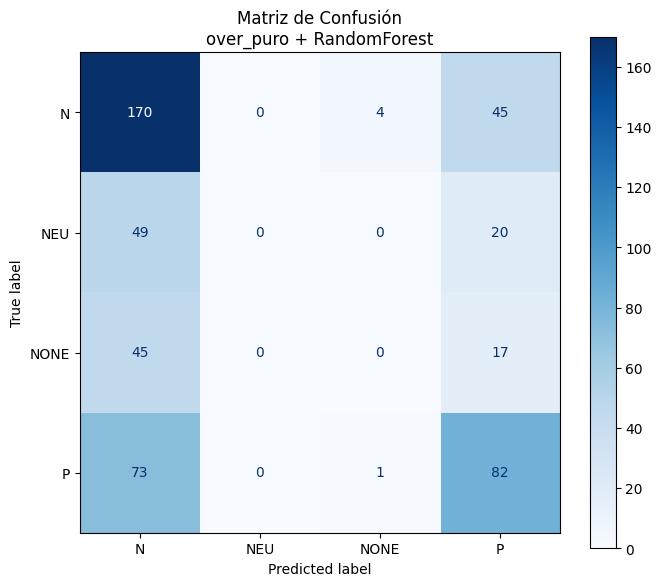


--- Tweets mal clasificados (muestra de 10) ---
Total errores: 254 de 506 (50.2%)

[1] Real: P      | Pred: N      | @piscolabisaereo @HistoriaNG @SPosteguillo las tengo pero aún no las he leído. C
[2] Real: P      | Pred: N      | Al final han sido 3h  Bueno, mañana tengo fiesta así que.. No me quejo
[5] Real: P      | Pred: N      | Tengo una perrina adorable... Sabéis que me acompaña hasta la a habitación cuand
[6] Real: NEU    | Pred: N      | @juankipua Es que en el Ojeando el año pasado tampoco, tiene muchas canciones ya
[7] Real: NONE   | Pred: N      | Bueno, estoy en la batalla final del Conquista y ya después me faltaría Revelaci
[8] Real: NONE   | Pred: P      | @CondeDuqueMAD ¿mañana sábado 31? En que día vives?  Mañana es miércoles 31.
[10] Real: P      | Pred: N      | @vitojph ¡sí! Y me ha encantado  ¿Tú ya las visto? ¿Cuándo comentamos?
[11] Real: NONE   | Pred: N      | @aladroqe Se me olvidaban los grandes @2qblog y @estapillao ! A ver si os intere
[12] Real: N      

In [ ]:
# ── Modelos ──────────────────────────────────────────────────────────────────
modelos = {
    'Softmax'     : LogisticRegression(multi_class="multinomial", solver="lbfgs",
                                        C=10, max_iter=1000),
    'SVM'         : SVC(kernel='linear', C=1, random_state=42),
    'NaiveBayes'  : MultinomialNB(),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradBoost'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN'         : KNeighborsClassifier(n_neighbors=5),
}

k_fold = ShuffleSplit(n_splits=10, test_size=0.25, random_state=42)

# ── Loop balanceos × modelos ─────────────────────────────────────────────────
resultados = {}

for nombre_balanceo, (X_b, y_b) in balanceos.items():
    y_b = np.array(y_b)
    resultados[nombre_balanceo] = {}

    for nombre_modelo, modelo in modelos.items():
        accuracies, recalls, precisions, f1s = [], [], [], []
        error = None

        try:
            for train_idx, val_idx in k_fold.split(X_b, y_b):
                X_tr,  y_tr  = X_b[train_idx], y_b[train_idx]
                X_val, y_val = X_b[val_idx],   y_b[val_idx]

                modelo.fit(X_tr, y_tr)
                pred = modelo.predict(X_val)

                accuracies.append(accuracy_score(y_val, pred))
                recalls.append(recall_score(y_val, pred, average='macro'))
                precisions.append(precision_score(y_val, pred, average='weighted',
                                                   zero_division=0))
                f1s.append(f1_score(y_val, pred, average='weighted'))

            resultados[nombre_balanceo][nombre_modelo] = {
                'Accuracy'  : round(np.mean(accuracies)  * 100, 2),
                'Recall'    : round(np.mean(recalls)      * 100, 2),
                'Precision' : round(np.mean(precisions)   * 100, 2),
                'F1'        : round(np.mean(f1s)          * 100, 2),
            }
        except Exception as e:
            resultados[nombre_balanceo][nombre_modelo] = None
            print(f"  ⚠ {nombre_balanceo} + {nombre_modelo}: {e}")

        print(f"  ✓ {nombre_balanceo:<15} + {nombre_modelo}")

print("\n✅ Experimentos completados\n")

# ── Tabla comparativa ────────────────────────────────────────────────────────
header = f"{'Balanceo':<15} {'Modelo':<15} {'Accuracy':>10} {'Recall':>8} {'Precision':>11} {'F1':>8}"
print(header)
print("-" * len(header))

mejor_f1     = 0
mejor_config = {}

for nombre_balanceo, modelos_res in resultados.items():
    for nombre_modelo, metricas in modelos_res.items():
        if metricas is None:
            print(f"{nombre_balanceo:<15} {nombre_modelo:<15} {'ERROR':>10}")
            continue
        print(f"{nombre_balanceo:<15} {nombre_modelo:<15} "
              f"{metricas['Accuracy']:>10} "
              f"{metricas['Recall']:>8} "
              f"{metricas['Precision']:>11} "
              f"{metricas['F1']:>8}")
        if metricas['F1'] > mejor_f1:
            mejor_f1     = metricas['F1']
            mejor_config = {'balanceo': nombre_balanceo, 'modelo': nombre_modelo,
                            'metricas': metricas}

print(f"\n🏆 Mejor configuración: {mejor_config['balanceo']} + {mejor_config['modelo']}")
print(f"   F1: {mejor_config['metricas']['F1']} | "
      f"Accuracy: {mejor_config['metricas']['Accuracy']} | "
      f"Recall: {mejor_config['metricas']['Recall']}")

# ── Evaluación final sobre test ──────────────────────────────────────────────
print("\n" + "="*60)
print("EVALUACIÓN FINAL SOBRE TEST (datos nunca vistos)")
print("="*60)

X_best, y_best = balanceos[mejor_config['balanceo']]
modelo_final   = modelos[mejor_config['modelo']]
modelo_final.fit(X_best, np.array(y_best))

y_pred_test = modelo_final.predict(x_test_bow)
y_test_arr  = np.array(y_test)

print(classification_report(y_test_arr, y_pred_test,
                             target_names=['N', 'NEU', 'NONE', 'P']))

# ── Matriz de confusión ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_arr, y_pred_test,
    display_labels=['N', 'NEU', 'NONE', 'P'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Matriz de Confusión\n{mejor_config['balanceo']} + {mejor_config['modelo']}")
plt.tight_layout()
plt.show()

# ── Análisis de errores ──────────────────────────────────────────────────────
print("\n--- Tweets mal clasificados (muestra de 10) ---")
tweets_test  = data_test['content'].tolist()
errores_idx  = [i for i, (real, pred) in enumerate(zip(y_test_arr, y_pred_test))
                if real != pred]

print(f"Total errores: {len(errores_idx)} de {len(y_test_arr)} "
      f"({round(len(errores_idx)/len(y_test_arr)*100,1)}%)\n")

for i in errores_idx[:10]:
    print(f"[{i}] Real: {y_test_arr[i]:<6} | Pred: {y_pred_test[i]:<6} | "
          f"{tweets_test[i][:80]}")